In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import libraries

In [2]:
df=pd.read_csv("../Data/raw/Amazon Sale Report.csv" )


C:\Users\Heart\AppData\Local\Temp\ipykernel_19712\238536067.py:1: DtypeWarning: Columns (0: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("../Data/raw/Amazon Sale Report.csv" )


Fetch Dataset

In [3]:
pd.set_option("Display.max_columns",None)

In [4]:
df.head(10)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
5,5,404-1490984-4578765,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,XL,B08YN7XDSG,Shipped,1,INR,824.00,GHAZIABAD,UTTAR PRADESH,201102.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
6,6,408-5748499-6859555,04-30-22,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,L,B08CMHNWBN,Shipped,1,INR,653.00,CHANDIGARH,CHANDIGARH,160036.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
7,7,406-7807733-3785945,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,S,B081WX4G4Q,Shipped,1,INR,399.00,HYDERABAD,TELANGANA,500032.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
8,8,407-5443024-5233168,04-30-22,Cancelled,Amazon,Amazon.in,Expedited,SET200,SET200-KR-NP-A-XXXL,Set,3XL,B08L91ZZXN,Cancelled,0,NaN,NaN,HYDERABAD,TELANGANA,500008.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
9,9,402-4393761-0311520,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3461,JNE3461-KR-XXL,kurta,XXL,B08B3XF5MH,Shipped,1,INR,363.00,Chennai,TAMIL NADU,600041.0,IN,NaN,False,NaN,NaN


Understanding the data

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


In [6]:
df["currency"].unique()

<StringArray>
['INR', nan]
Length: 2, dtype: str

In [7]:
df.drop(columns=["Unnamed: 22","ship-country","currency","index"],inplace=True)

Data Cleaning

In [8]:
df.shape

(128975, 20)

In [9]:
df.dropna(subset=["Amount"],inplace=True)

Feature engineering

In [10]:
new_date=pd.to_datetime(df["Date"],format="%m-%d-%y")

In [11]:
df["Date"]=new_date

In [12]:
month=df["Date"].dt.month

In [13]:
df["new_month"]=month

In [14]:
year=df["Date"].dt.year


In [15]:
df["new_year"]=year

In [16]:
df["new_month"].unique()

array([4, 3, 5, 6], dtype=int32)

In [17]:
df.groupby("Category")["Amount"].sum()

Category
Blouse             458408.18
Bottom             150667.98
Dupatta               915.00
Ethnic Dress       791217.66
Saree              123933.76
Set              39204124.03
Top               5347792.30
Western Dress    11216072.69
kurta            21299546.70
Name: Amount, dtype: float64

In [18]:
df[df["Category"] == "Set"].groupby("ship-state")["Amount"].sum()

ship-state
ANDAMAN & NICOBAR       92160.32
ANDHRA PRADESH        1462219.63
ARUNACHAL PRADESH       51914.95
ASSAM                  572864.00
Arunachal Pradesh        1235.00
BIHAR                  923430.86
Bihar                   14389.00
CHANDIGARH             113145.14
CHHATTISGARH           337123.23
Chandigarh               3414.00
DADRA AND NAGAR         28439.92
DELHI                 2372061.67
Delhi                   43402.34
GOA                    260109.89
Goa                      5137.00
Gujarat               1290839.42
HARYANA               1620143.96
HIMACHAL PRADESH       340570.08
JAMMU & KASHMIR        305793.31
JHARKHAND              562724.44
KARNATAKA             4975448.28
KERALA                1481258.67
LADAKH                  33237.43
LAKSHADWEEP              1670.00
MADHYA PRADESH         910867.13
MAHARASHTRA           6273304.71
MANIPUR                137487.52
MEGHALAYA               62039.66
MIZORAM                 21392.61
Manipur                   999.00

In [19]:
df["ship-state"]=df["ship-state"].str.strip().str.upper()

In [20]:
df[df["Category"]=="Set"].groupby("ship-state")["Amount"].sum()

ship-state
ANDAMAN & NICOBAR      92160.32
ANDHRA PRADESH       1462219.63
ARUNACHAL PRADESH      53149.95
ASSAM                 572864.00
BIHAR                 939251.86
CHANDIGARH            116559.14
CHHATTISGARH          337123.23
DADRA AND NAGAR        28439.92
DELHI                2425862.63
GOA                   266671.89
GUJARAT              1290839.42
HARYANA              1620143.96
HIMACHAL PRADESH      340570.08
JAMMU & KASHMIR       305793.31
JHARKHAND             562724.44
KARNATAKA            4975448.28
KERALA               1481258.67
LADAKH                 33237.43
LAKSHADWEEP             1670.00
MADHYA PRADESH        910867.13
MAHARASHTRA          6273304.71
MANIPUR               138486.52
MEGHALAYA              62610.14
MIZORAM                21392.61
NAGALAND              106694.48
NEW DELHI              25573.95
ODISHA                782432.78
ORISSA                  1361.00
PUDUCHERRY             72159.57
PUNJAB                703175.80
RAJASTHAN            1067974.

In [21]:
df["ship-state"].unique()

<StringArray>
[           'MAHARASHTRA',              'KARNATAKA',             'PUDUCHERRY',
             'TAMIL NADU',          'UTTAR PRADESH',             'CHANDIGARH',
              'TELANGANA',         'ANDHRA PRADESH',              'RAJASTHAN',
                  'DELHI',                'HARYANA',                  'ASSAM',
              'JHARKHAND',           'CHHATTISGARH',                 'ODISHA',
                 'KERALA',         'MADHYA PRADESH',            'WEST BENGAL',
               'NAGALAND',                'GUJARAT',            'UTTARAKHAND',
                  'BIHAR',        'JAMMU & KASHMIR',                 'PUNJAB',
       'HIMACHAL PRADESH',      'ARUNACHAL PRADESH',                'MANIPUR',
                    'GOA',              'MEGHALAYA',                'TRIPURA',
                 'LADAKH',        'DADRA AND NAGAR',                 'SIKKIM',
                      nan,      'ANDAMAN & NICOBAR',              'RAJSHTHAN',
                     'NL',            

In [22]:
monthly_sales=df[df["new_month"]==4].groupby("Category")["Amount"].sum()

In [23]:
monthly_sales

Category
Blouse             195583.21
Bottom              63308.45
Ethnic Dress       250666.65
Saree               55655.24
Set              15506675.56
Top               1821893.22
Western Dress     2927780.51
kurta             8017145.48
Name: Amount, dtype: float64

In [24]:
df.dropna(subset=["ship-state"],inplace=True)

In [25]:
state_map = {
    # Rajasthan
    "RJ": "RAJASTHAN",
    "RAJSTHAN": "RAJASTHAN",
    "RAJSHTHAN": "RAJASTHAN",

    # Punjab
    "PB": "PUNJAB",
    "PUNJAB/MOHALI/ZIRAKPUR": "PUNJAB",

    # Odisha
    "ORISSA": "ODISHA",

    # Puducherry
    "PONDICHERRY": "PUDUCHERRY",

    # Arunachal Pradesh
    "AR": "ARUNACHAL PRADESH",

    # Delhi
    "NEW DELHI": "DELHI",

    # Nagaland
    "NL": "NAGALAND",

    # Dadra and Nagar Haveli
    "DADRA AND NAGAR": "DADRA AND NAGAR HAVELI AND DAMAN AND DIU",

    # Jammu & Kashmir
    "JAMMU AND KASHMIR": "JAMMU & KASHMIR",

    # Andhra Pradesh variations
    "ANDHRA PRADESH ": "ANDHRA PRADESH",

    # Uttar Pradesh variations
    "UP": "UTTAR PRADESH",

    # Tamil Nadu variations
    "TN": "TAMIL NADU",

    # Karnataka variations
    "KA": "KARNATAKA",

    # Maharashtra variations
    "MH": "MAHARASHTRA",

    # Gujarat variations
    "GJ": "GUJARAT",

    # Haryana variations
    "HR": "HARYANA",

    # Kerala variations
    "KL": "KERALA",

    # Madhya Pradesh variations
    "MP": "MADHYA PRADESH",

    # West Bengal variations
    "WB": "WEST BENGAL",

    # Bihar variations
    "BR": "BIHAR",

    # Chhattisgarh variations
    "CG": "CHHATTISGARH",

    # Telangana variations
    "TS": "TELANGANA",

    # Uttarakhand variations
    "UK": "UTTARAKHAND",

    # Himachal Pradesh variations
    "HP": "HIMACHAL PRADESH",

    # Assam variations
    "AS": "ASSAM",

    # Goa variations
    "GA": "GOA",

    # Sikkim variations
    "SK": "SIKKIM",

    # Meghalaya variations
    "ML": "MEGHALAYA",

    # Tripura variations
    "TR": "TRIPURA",

    # Mizoram variations
    "MZ": "MIZORAM",

    # Manipur variations
    "MN": "MANIPUR",

    # Nagaland variations
    "NL": "NAGALAND",

    # Lakshadweep variations
    "LD": "LAKSHADWEEP",

    # Andaman & Nicobar variations
    "A & N ISLANDS": "ANDAMAN & NICOBAR",

    # Chandigarh variations
    "CHD": "CHANDIGARH"
}

In [26]:
df[df["ship-state"]=="RAJASTHAN"].groupby("Category")["Amount"].sum()

Category
Blouse              5066.00
Bottom              3363.00
Ethnic Dress       13430.00
Saree               2560.00
Set              1067974.16
Top               101012.95
Western Dress     176736.64
kurta             387858.41
Name: Amount, dtype: float64

In [27]:
df["ship-state"] = df["ship-state"].replace(state_map)

In [28]:
df[df["ship-state"]=="MIZORAM"].groupby("Category")["Amount"].sum()

Category
Ethnic Dress       566.00
Set              21392.61
Top               7758.00
Western Dress     2590.00
kurta             9642.10
Name: Amount, dtype: float64

In [29]:
sale_Mizoram=df[df["ship-state"]=="MIZORAM"].groupby("Category")["Amount"].sum()

In [30]:
mizoram_sales_int_april=df[(df["ship-state"] == "MIZORAM") & (df["new_month"] == 4)].groupby("Category")["Amount"].sum()

Text(0, 0.5, 'Amount')

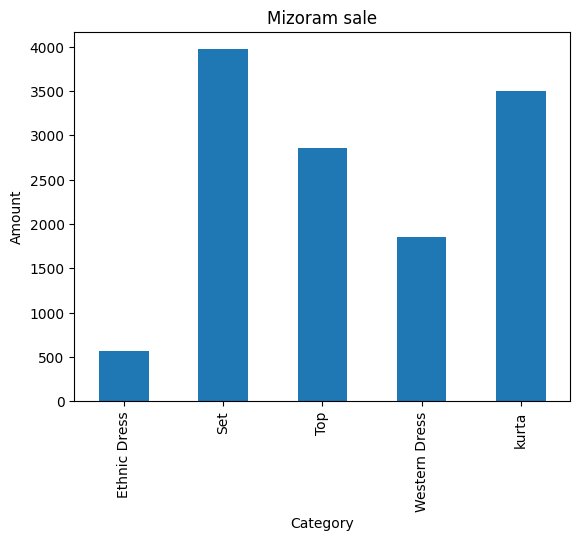

In [31]:
mizoram_sales_int_april.plot(kind="bar")
plt.title("Mizoram sale")
plt.xlabel("Category")
plt.ylabel("Amount")

Data Visualization and EDA

<Axes: xlabel='new_month'>

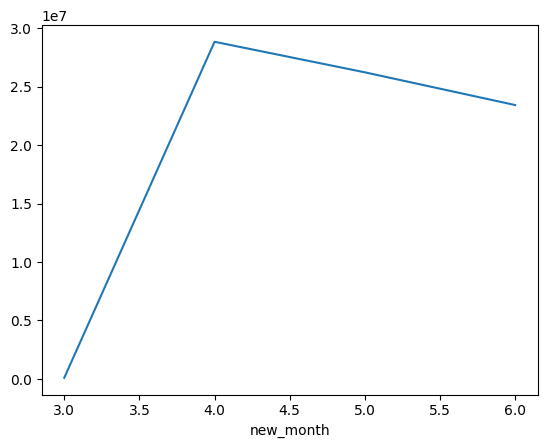

In [32]:
df.groupby("new_month")["Amount"].sum().plot(kind="line")

Text(0, 0.5, 'Amount')

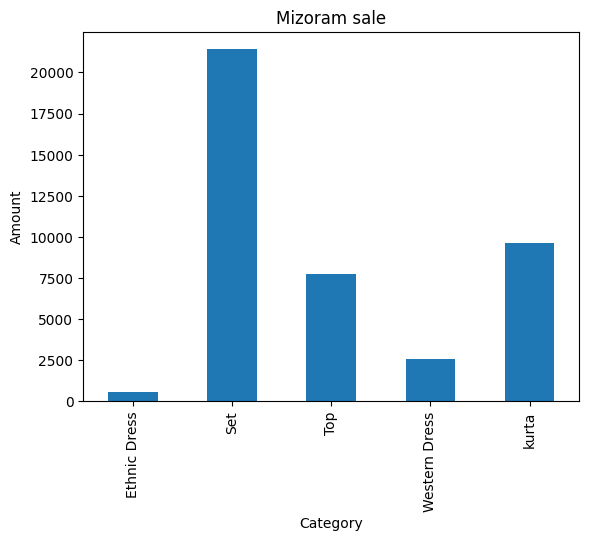

In [33]:
sale_Mizoram.plot(kind="bar")
plt.title("Mizoram sale")
plt.xlabel("Category")
plt.ylabel("Amount")

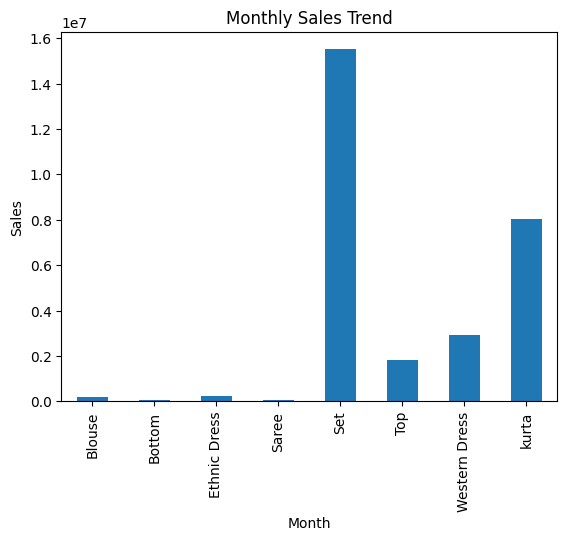

In [34]:
monthly_sales.plot(kind='bar')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

<Axes: xlabel='Category'>

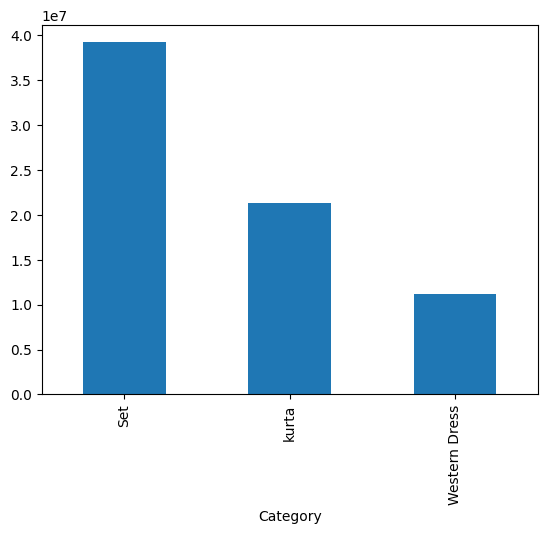

In [35]:
df.groupby("Category")["Amount"].sum().sort_values(ascending=False).head(3).plot(kind="bar")

# Amazon Sales Data Analytics Report

## Project Overview

This project analyzes the Amazon Sales Report dataset using Python libraries such as Pandas and Matplotlib. The main objective of this analysis is to understand sales trends, category performance, state-wise sales distribution, and monthly business performance.

---

# Steps Performed in Data Analytics

## 1. Import Libraries

The required libraries such as Pandas and Matplotlib were imported for data cleaning, analysis, and visualization.

```python
import pandas as pd
import matplotlib.pyplot as plt
```

---

## 2. Data Collection

The dataset was loaded from a CSV file using Pandas.

```python
df = pd.read_csv("Amazon Sale Report.csv")
```

---

## 3. Understanding the Dataset

The dataset structure, columns, data types, and missing values were checked using:

```python
df.info()
df.head()
df.shape
```

This helped in understanding the quality and structure of the dataset.

---

## 4. Data Cleaning

Several cleaning operations were performed:

* Removed unnecessary columns.
* Removed rows with missing Amount values.
* Standardized state names.
* Fixed spelling mistakes and duplicate state representations.

Example:

```python
df.dropna(subset=["Amount"], inplace=True)
```

---

## 5. Feature Engineering

New features were created from the Date column.

* Extracted Month
* Extracted Year

```python
df["new_month"] = df["Date"].dt.month
```

This made monthly analysis easier.

---

## 6. Exploratory Data Analysis (EDA)

Different analyses were performed:

### Category-wise Sales Analysis

Used groupby() to find total sales by category.

### State-wise Sales Analysis

Analyzed which states generated higher revenue.

### Monthly Sales Analysis

Checked sales trends for different months.

### Mizoram Sales Analysis

Special analysis was performed for Mizoram state and April month sales.

---

## 7. Data Visualization

Different graphs were created using Matplotlib:

* Bar Charts
* Line Charts
* Sales Trend Graphs

Example:

```python
monthly_sales.plot(kind='bar')
```

Visualizations helped in understanding sales patterns easily.

---

# Conclusion and Data Insights

## Key Findings

1. The dataset required significant cleaning because many state names were inconsistent and some records contained missing values.

2. The "Set" category generated one of the highest sales among all product categories.

3. Monthly sales analysis showed that sales varied across different months, indicating seasonal demand patterns.

4. Some states contributed much higher revenue compared to others, showing uneven sales distribution across India.

5. Mizoram had comparatively lower sales than major states, but category-wise analysis still helped identify customer preferences.

6. Data visualization made it easier to identify trends, high-performing categories, and monthly growth patterns.

7. Feature engineering using month and year extraction improved the analysis and allowed better business insights.

---

# Business Insights

* The company should focus more on high-performing categories to increase revenue.
* Low-performing states can be targeted with marketing campaigns and discounts.
* Seasonal sales trends can help in inventory planning.
* Proper data cleaning is important because incorrect state names can affect business reports.

---

# Final Result

This project successfully performed:

* Data Cleaning
* Data Transformation
* Exploratory Data Analysis
* Data Visualization
* Business Insight Generation

The analysis provided meaningful insights into Amazon sales performance and customer purchasing trends.

---

# Technologies Used

* Python
* Pandas
* Matplotlib
* Jupyter Notebook

---

# Overall Summary

The project demonstrates how raw sales data can be converted into meaningful business insights using data analytics techniques. By performing cleaning, analysis, and visualization, important trends and sales patterns were identified successfully.
